In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot
from scipy.stats import linregress


# FBG-7 (450μm) – 3 days: 27-02-2025, 28-02-2025, 10-03-2025

Combined analysis of the three PEEK-7 days. This notebook replicates the global sensitivity repeatability analysis as in PEEK-1.


---

## **Cross-Experiment Comparison: PEEK-7 Thermal Sensitivity (ver 3 notebooks de nombre peek-7, el análisis final está en el del dia 10-03)**

This table compares the thermal sensitivity results from three different experiments conducted on the PEEK-7 fiber between February and March 2025.

### **Statistical Summary by Experiment**

| Experiment Date | Mean Sensitivity (pm/K) | Std. Dev. (pm/K) | CV (%) | Range (pm/K) | Min | Max |
|-----------------|------------------------|------------------|--------|--------------|-----|-----|
| **Feb 27, 2025** | 20.437 | 1.512 | 7.40 | 3.726 | 18.611 | 22.337 |
| **Feb 28, 2025** | 19.735 | 0.207 | 1.05 | 0.511 | 19.429 | 19.940 |
| **Mar 10, 2025** | 19.469 | 0.325 | 1.67 | 0.812 | 19.025 | 19.837 |

### **Key Observations**

1. **Measurement Consistency**: 
   - Feb 28 shows the best consistency (CV = 1.05%), indicating highly stable experimental conditions
   - Feb 27 shows higher variability (CV = 7.40%), suggesting less controlled conditions or initial calibration phase
   - Mar 10 maintains good consistency (CV = 1.67%), confirming improved measurement stability

2. **Temporal Trend**: 
   - Experiments conducted in March show better repeatability than early February
   - Mean sensitivity converges toward **~19.5 pm/K** as the typical value for PEEK-7 fiber

3. **Sensor Performance**: 
   - All 6 measurements (3 sensors × 2 polarizations) across all experiments show R² > 0.99
   - Excellent linear response confirms FBG quality and measurement reliability

4. **Typical Range**: 
   - PEEK-7 thermal sensitivity: **19.0 - 20.5 pm/K**
   - Variability between sensors: typically < 2% (CV) under stable conditions

### **Individual Sensor Comparison**

| Sensor | Pol | Feb 27 (pm/K) | Feb 28 (pm/K) | Mar 10 (pm/K) | Mean | Std Dev |
|--------|-----|---------------|---------------|---------------|------|---------|
| 1 | P | 18.644 | 19.429 | 19.025 | 19.033 | 0.393 |
| 1 | S | 18.611 | 19.471 | 19.038 | 19.040 | 0.430 |
| 2 | P | 20.357 | 19.895 | 19.837 | 20.030 | 0.288 |
| 2 | S | 20.352 | 19.940 | 19.765 | 20.019 | 0.311 |
| 3 | P | 22.320 | 19.782 | 19.519 | 20.540 | 1.534 |
| 3 | S | 22.337 | 19.891 | 19.629 | 20.619 | 1.502 |

**Notes**:
- Sensor 3 shows higher variability across experiments, particularly in Feb 27 data
- Sensors 1 and 2 maintain more consistent values across all three experiments
- Polarization effects (P vs S) are minimal and within measurement uncertainty for most sensors

---

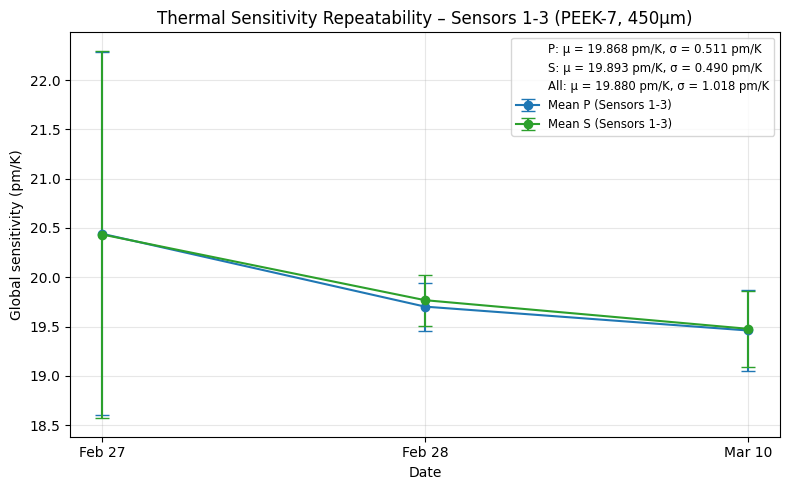

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de tu tabla "Individual Sensor Comparison"
dates = ['Feb 27', 'Feb 28', 'Mar 10']

# Sensor 1, 2, 3 para Polarización P
p_vals = np.array([
    [18.644, 19.429, 19.025], # Sensor 1
    [20.357, 19.895, 19.837], # Sensor 2
    [22.320, 19.782, 19.519]  # Sensor 3
])

# Sensor 1, 2, 3 para Polarización S
s_vals = np.array([
    [18.611, 19.471, 19.038], # Sensor 1
    [20.352, 19.940, 19.765], # Sensor 2
    [22.337, 19.891, 19.629]  # Sensor 3
])

# Calculamos medias y sigmas por día para cada polarización
p_means = np.mean(p_vals, axis=0)
p_std   = np.std(p_vals, axis=0, ddof=1)
s_means = np.mean(s_vals, axis=0)
s_std   = np.std(s_vals, axis=0, ddof=1)

# Estadísticas globales (los 18 puntos combinados)
all_data = np.concatenate([p_vals.flatten(), s_vals.flatten()])
mean_all = np.mean(all_data)
std_all  = np.std(all_data, ddof=1)

# Plot
plt.figure(figsize=(8,5))
colors = {'P': 'tab:blue', 'S': 'tab:green'}

# Dibujamos las líneas de P y S (media de los 3 sensores)
plt.errorbar(dates, p_means, yerr=p_std, fmt='o-', color=colors['P'], capsize=5, label='Mean P (Sensors 1-3)')
plt.errorbar(dates, s_means, yerr=s_std, fmt='o-', color=colors['S'], capsize=5, label='Mean S (Sensors 1-3)')

# Añadir a la leyenda μ y σ por polarización (promediando los 3 días)
for label, means, stds, col in [('P', p_means, p_std, 'P'), ('S', s_means, s_std, 'S')]:
    m_pol = np.mean(means)
    s_pol = np.std(means, ddof=1)
    plt.plot([], [], ' ', label=f"{label}: μ = {m_pol:.3f} pm/K, σ = {s_pol:.3f} pm/K")

plt.plot([], [], ' ', label=f"All: μ = {mean_all:.3f} pm/K, σ = {std_all:.3f} pm/K")

plt.xlabel('Date')
plt.ylabel('Global sensitivity (pm/K)')
plt.title('Thermal Sensitivity Repeatability – Sensors 1-3 (PEEK-7, 450μm)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

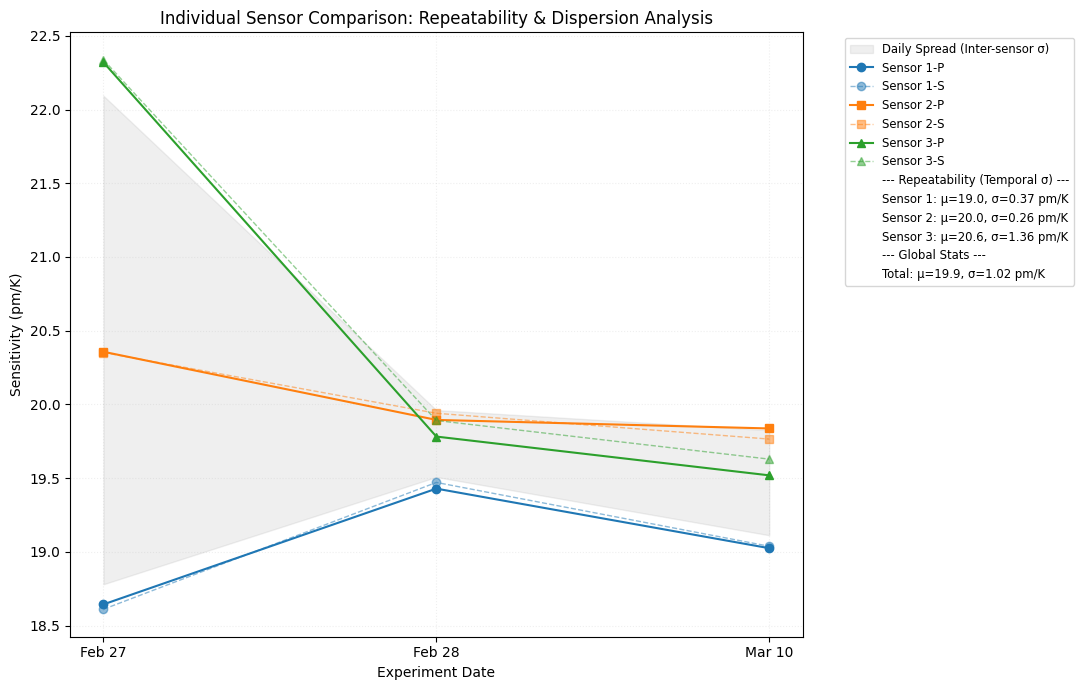

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos de entrada (de tu tabla "Individual Sensor Comparison")
dates = ['Feb 27', 'Feb 28', 'Mar 10']

# Datos por sensor [Feb 27, Feb 28, Mar 10]
s1_p, s1_s = [18.644, 19.429, 19.025], [18.611, 19.471, 19.038]
s2_p, s2_s = [20.357, 19.895, 19.837], [20.352, 19.940, 19.765]
s3_p, s3_s = [22.320, 19.782, 19.519], [22.337, 19.891, 19.629]

# 2. Cálculos estadísticos
all_sensors = [ (s1_p, s1_s), (s2_p, s2_s), (s3_p, s3_s) ]
all_data_matrix = np.array([s1_p, s1_s, s2_p, s2_s, s3_p, s3_s])

# Dispersión diaria (franja gris)
daily_means = np.mean(all_data_matrix, axis=0)
daily_sigmas = np.std(all_data_matrix, axis=0, ddof=1)

# 3. Configuración del Plot
plt.figure(figsize=(11, 7))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
markers = {0: 'o', 1: 's', 2: '^'}

# A. Franja de dispersión diaria (±1σ entre todos los sensores)
plt.fill_between(dates, daily_means - daily_sigmas, daily_means + daily_sigmas, 
                 color='gray', alpha=0.12, label='Daily Spread (Inter-sensor σ)')

# B. Series individuales
for i, (p_vals, s_vals) in enumerate(all_sensors):
    sensor_num = i + 1
    # Graficar P y S
    plt.plot(dates, p_vals, color=colors[i], marker=markers[i], linestyle='-', 
             linewidth=1.5, label=f'Sensor {sensor_num}-P')
    plt.plot(dates, s_vals, color=colors[i], marker=markers[i], linestyle='--', 
             alpha=0.5, linewidth=1, label=f'Sensor {sensor_num}-S')

# C. Añadir repetibilidad por sensor a la leyenda (μ y σ temporal de cada uno)
plt.plot([], [], ' ', label="--- Repeatability (Temporal σ) ---")
for i, (p_vals, s_vals) in enumerate(all_sensors):
    combined_sensor_data = np.array(p_vals + s_vals)
    mu_sensor = np.mean(combined_sensor_data)
    sigma_sensor = np.std(combined_sensor_data, ddof=1)
    plt.plot([], [], ' ', label=f"Sensor {i+1}: μ={mu_sensor:.1f}, σ={sigma_sensor:.2f} pm/K")

# D. Estadística Global
mu_total = np.mean(all_data_matrix)
sigma_total = np.std(all_data_matrix, ddof=1)
plt.plot([], [], ' ', label="--- Global Stats ---")
plt.plot([], [], ' ', label=f"Total: μ={mu_total:.1f}, σ={sigma_total:.2f} pm/K")

# 4. Formateo
plt.xlabel('Experiment Date')
plt.ylabel('Sensitivity (pm/K)')
plt.title('Individual Sensor Comparison: Repeatability & Dispersion Analysis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', frameon=True)
plt.grid(True, alpha=0.2, linestyle=':')
plt.tight_layout()

plt.show()

A los tiempos de 'wav' del día 27 hay que sumarles una hora y los tiempos comunes son: 

# Plateaus de temperatura (ejemplo, puedes completar con todos)
plateaus_temp = [
    {"t0": "2025-02-27 13:54:05", "tfin": "2025-02-27 14:41:45"},
    {"t0": "2025-02-27 14:52:05", "tfin": "2025-02-27 15:37:35"},
    {"t0": "2025-02-27 15:46:35", "tfin": "2025-02-27 16:02:25"},
    {"t0": "2025-02-27 16:10:55", "tfin": "2025-02-27 16:32:35"},
    {"t0": "2025-02-27 16:43:15", "tfin": "2025-02-27 16:56:35"},
    {"t0": "2025-02-27 17:13:55", "tfin": "2025-02-27 17:33:45"},
    {"t0": "2025-02-27 17:41:35", "tfin": "2025-02-27 18:32:35"},
]

A los tiempos de 'wav' del día 28 también hay que sumarle una hora a las 'wav' y los plateaus son:
plateaus = {
    1: {"t0": "2025-02-28 14:28:43.364741", "tfin": "2025-02-28 14:44:53.364741"},
    2: {"t0": "2025-02-28 14:45:43.364741", "tfin": "2025-02-28 15:06:23.364741"},
    3: {"t0": "2025-02-28 15:17:23.364741", "tfin": "2025-02-28 15:41:43.364741"},
    4: {"t0": "2025-02-28 15:43:53.364741", "tfin": "2025-02-28 16:02:13.364741"},
    5: {"t0": "2025-02-28 16:05:23.364741", "tfin": "2025-02-28 16:18:03.364741"},
    6: {"t0": "2025-02-28 16:19:43.364741", "tfin": "2025-02-28 16:30:13.364741"},
    7: {"t0": "2025-02-28 16:32:03.364741", "tfin": "2025-02-28 16:39:43.364741"},
}


A los tiempos de 'wav' del día 10 también se le suman una hora: 

plateaus = {
    0: {"t0": "2025-03-10 14:39:31", "tfin": "2025-03-10 15:16:11"},
    1: {"t0": "2025-03-10 15:20:51", "tfin": "2025-03-10 15:42:21"},
    2: {"t0": "2025-03-10 16:00:51", "tfin": "2025-03-10 16:33:01"},
    3: {"t0": "2025-03-10 16:38:21", "tfin": "2025-03-10 17:01:31"},
}




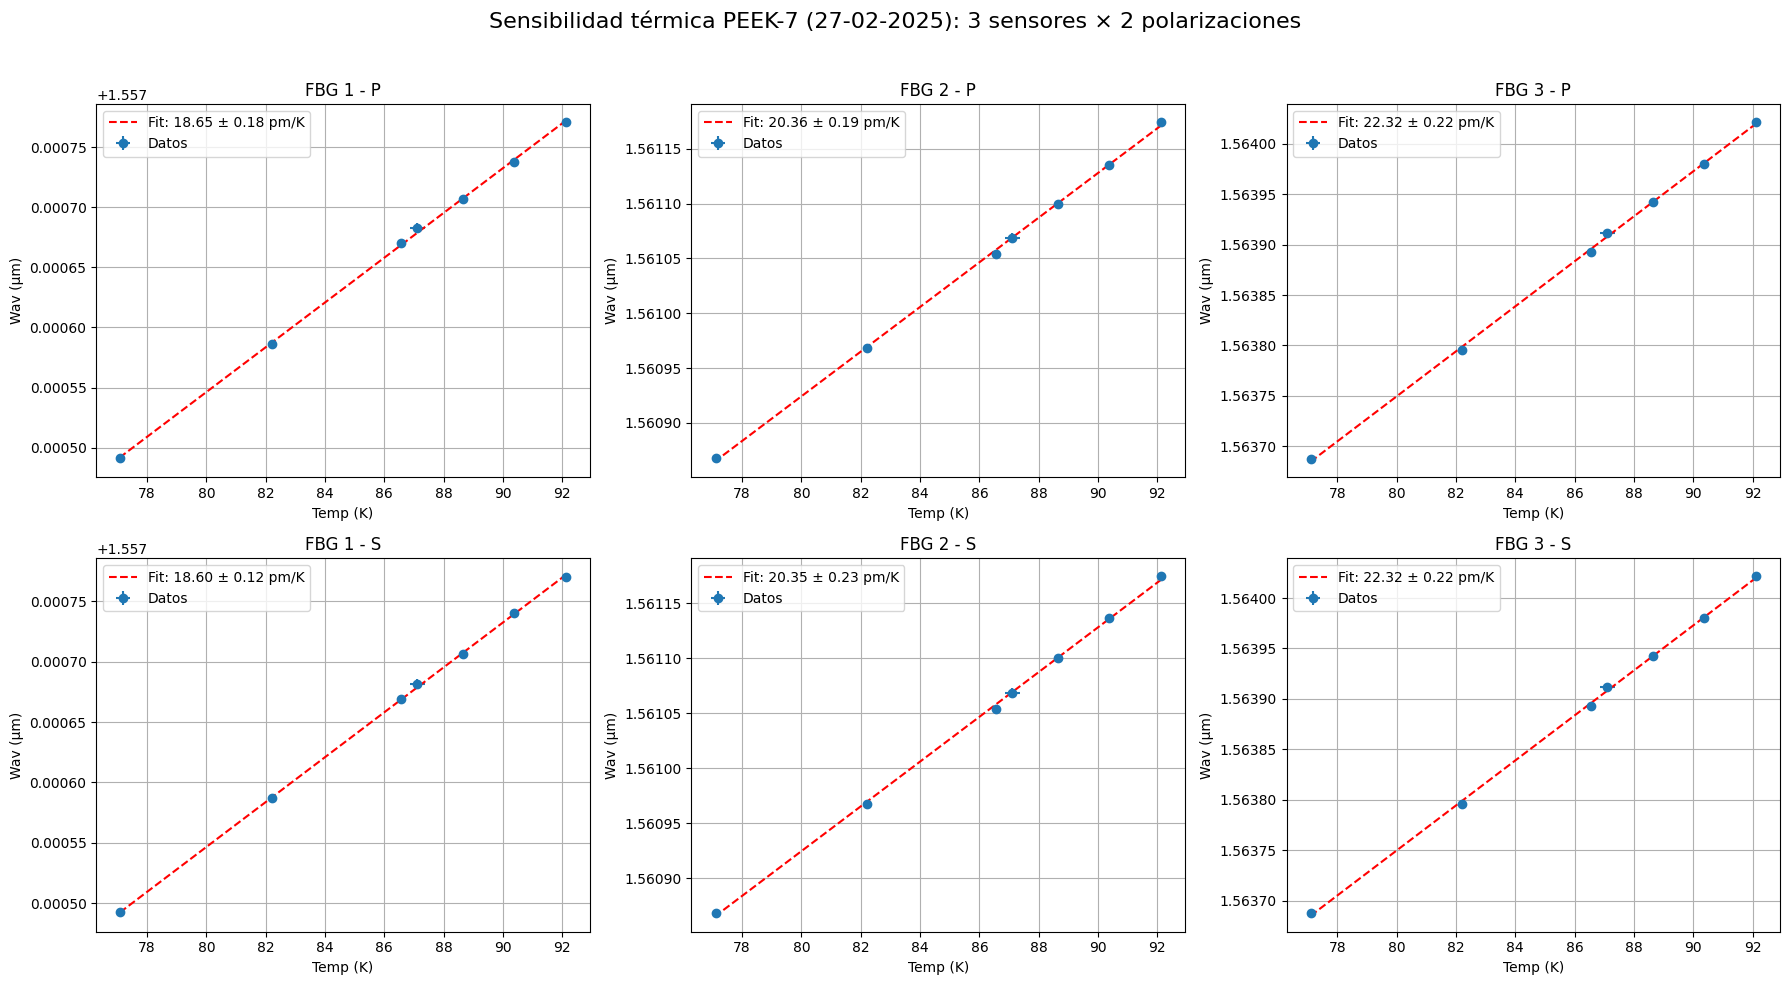

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress

# --- Parámetros y plateaus comunes ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/resampled20250227.root"
plateaus_temp = [
    {"t0": "2025-02-27 13:54:05", "tfin": "2025-02-27 14:41:45"},
    {"t0": "2025-02-27 14:52:05", "tfin": "2025-02-27 15:37:35"},
    {"t0": "2025-02-27 15:46:35", "tfin": "2025-02-27 16:02:25"},
    {"t0": "2025-02-27 16:10:55", "tfin": "2025-02-27 16:32:35"},
    {"t0": "2025-02-27 16:43:15", "tfin": "2025-02-27 16:56:35"},
    {"t0": "2025-02-27 17:13:55", "tfin": "2025-02-27 17:33:45"},
    {"t0": "2025-02-27 17:41:35", "tfin": "2025-02-27 18:32:35"},
]

# --- Cargar datos ---
with uproot.open(input_filename) as file:
    tree = file["resampled_data"]
    data = tree.arrays(library="np")

times = data["t"]
timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])
temp = data["temp"]
wav = data["wav"]  # shape: (N, 2, 3) [pol, sensor]

# --- Función para extraer medias y stds en plateaus ---
def get_plateau_stats(timestamps, values, plateaus, time_shift_hours=0):
    means, stds = [], []
    # Aplicar time shift si es necesario
    if time_shift_hours != 0:
        timestamps = np.array([t + datetime.timedelta(hours=time_shift_hours) for t in timestamps])
    for p in plateaus:
        t0 = datetime.datetime.strptime(p["t0"], "%Y-%m-%d %H:%M:%S")
        tfin = datetime.datetime.strptime(p["tfin"], "%Y-%m-%d %H:%M:%S")
        mask = (timestamps >= t0) & (timestamps <= tfin)
        vals = values[mask]
        means.append(np.mean(vals) if len(vals) > 0 else np.nan)
        stds.append(np.std(vals) if len(vals) > 0 else np.nan)
    return np.array(means), np.array(stds)

# --- Calcular medias y stds para cada sensor/pol ---
results = {}
for pol in range(2):  # 0=P, 1=S
    for sensor in range(3):  # 0,1,2
        # Filtrar wav para cada sensor/pol
        wav_vals = wav[:, pol, sensor]
        # Filtrar valores de wav válidos (umbral)
        if sensor == 0:
            umbral_min, umbral_max = 1.5574e-6, 1.5578e-6
        elif sensor == 1:
            umbral_min, umbral_max = 1.56e-6, 1.56148e-6
        else:
            umbral_min, umbral_max = 1.563e-6, 1.5642e-6
        mask = (wav_vals > umbral_min) & (wav_vals < umbral_max)
        wav_valid = wav_vals[mask]
        wav_times = timestamps[mask]
        # Sumar 1 hora a los tiempos de wav
        wav_means, wav_stds = get_plateau_stats(wav_times, wav_valid*1e6, plateaus_temp, time_shift_hours=1)
        # Temperatura: sensor 7 para FBG1,2,3 (ajustar si necesario)
        temp_means, temp_stds = get_plateau_stats(timestamps, temp[:,7], plateaus_temp)
        results[(sensor, pol)] = {
            "wav_means": wav_means,
            "wav_stds": wav_stds,
            "temp_means": temp_means,
            "temp_stds": temp_stds
        }

# --- Graficar los 6 fits ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)  # Ejes independientes por subplot
for idx, ((sensor, pol), res) in enumerate(results.items()):
    ax = axs[pol, sensor]
    # Ajuste lineal ignorando NaN
    mask = ~np.isnan(res["wav_means"]) & ~np.isnan(res["temp_means"])
    if np.sum(mask) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(res["temp_means"][mask], res["wav_means"][mask])
        fit_line = slope * res["temp_means"][mask] + intercept
        ax.errorbar(res["temp_means"], res["wav_means"], xerr=res["temp_stds"], yerr=res["wav_stds"], fmt='o', label="Datos")
        ax.plot(res["temp_means"][mask], fit_line, 'r--', label=f'Fit: {slope*1e6:.2f} ± {std_err*1e6:.2f} pm/K')
        ax.set_title(f"FBG {sensor+1} - {'P' if pol==0 else 'S'}")
        # Ajustar eje y a los datos disponibles (con margen, por subplot)
        ydata = res["wav_means"][mask]
        yerr = res["wav_stds"][mask]
        if len(ydata) > 0 and not np.all(np.isnan(ydata)):
            ymin = np.nanmin(ydata - yerr)
            ymax = np.nanmax(ydata + yerr)
            yrange = ymax - ymin
            ax.set_ylim(ymin - 0.05*yrange, ymax + 0.05*yrange)
        ax.set_xlabel("Temp (K)")
        ax.set_ylabel("Wav (μm)")
        ax.legend()
        ax.grid(True)
plt.suptitle("Sensibilidad térmica PEEK-7 (27-02-2025): 3 sensores × 2 polarizaciones", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [5]:
import pandas as pd

# --- Extraer resultados y crear DataFrame ---
summary_data = []
fecha_experimento = "2025-02-27"

for (sensor_idx, pol_idx), res in results.items():
    # Máscara para ignorar NaNs
    mask = ~np.isnan(res["wav_means"]) & ~np.isnan(res["temp_means"])
    
    if np.sum(mask) > 1:
        # Volvemos a calcular el fit para extraer los datos al DF
        slope, intercept, r_value, p_value, std_err = linregress(
            res["temp_means"][mask], 
            res["wav_means"][mask]
        )
        
        # Guardamos en pm/K (multiplicando por 1e6 ya que wav_means está en µm)
        slope_pmk = slope * 1e6
        error_pmk = std_err * 1e6
        
        summary_data.append({
            "Date": fecha_experimento,
            "Sensor": f"FBG {sensor_idx + 1}",
            "Pol": "P" if pol_idx == 0 else "S",
            "Slope_pmK": round(slope_pmk, 3),
            "Error_pmK": round(error_pmk, 3),
            "R2": round(r_value**2, 5)
        })

# Crear DataFrame
df_results_27_02 = pd.DataFrame(summary_data)

# --- Imprimir resumen formateado ---
print(f"Resumen de Sensibilidades - {fecha_experimento}")
print("-" * 60)
print(df_results_27_02.to_string(index=False))
print("-" * 60)

# Opcional: Mostrar el DF estilizado (si usas Jupyter)
# display(df_results_27_02)

Resumen de Sensibilidades - 2025-02-27
------------------------------------------------------------
      Date Sensor Pol  Slope_pmK  Error_pmK      R2
2025-02-27  FBG 1   P     18.650      0.177 0.99955
2025-02-27  FBG 2   P     20.358      0.186 0.99958
2025-02-27  FBG 3   P     22.318      0.217 0.99953
2025-02-27  FBG 1   S     18.603      0.121 0.99979
2025-02-27  FBG 2   S     20.348      0.230 0.99936
2025-02-27  FBG 3   S     22.322      0.217 0.99953
------------------------------------------------------------


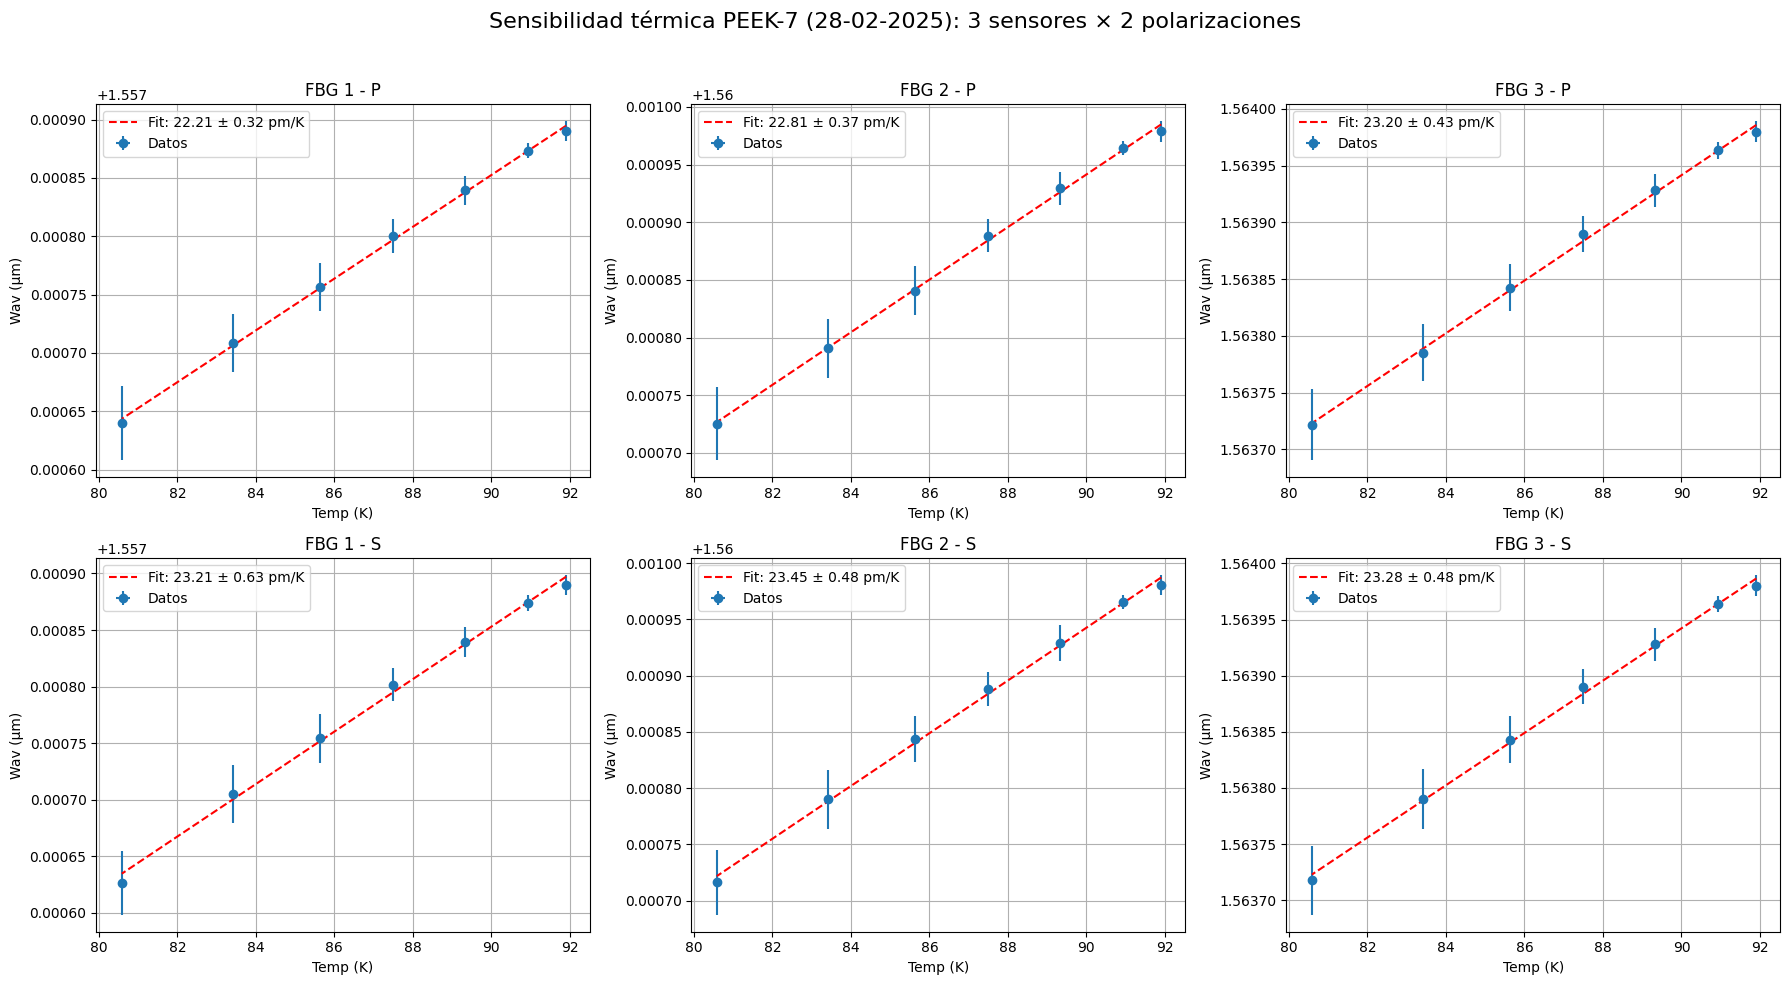

In [6]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress

# --- Parámetros y plateaus comunes ---
input_filename = '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/resampled20250228.root'
plateaus = [
    {'t0': '2025-02-28 14:28:43.364741', 'tfin': '2025-02-28 14:44:53.364741'},
    {'t0': '2025-02-28 14:45:43.364741', 'tfin': '2025-02-28 15:06:23.364741'},
    {'t0': '2025-02-28 15:17:23.364741', 'tfin': '2025-02-28 15:41:43.364741'},
    {'t0': '2025-02-28 15:43:53.364741', 'tfin': '2025-02-28 16:02:13.364741'},
    {'t0': '2025-02-28 16:05:23.364741', 'tfin': '2025-02-28 16:18:03.364741'},
    {'t0': '2025-02-28 16:19:43.364741', 'tfin': '2025-02-28 16:30:13.364741'},
    {'t0': '2025-02-28 16:32:03.364741', 'tfin': '2025-02-28 16:39:43.364741'},
]

# --- Cargar datos ---
with uproot.open(input_filename) as file:
    tree = file['resampled_data']
    data = tree.arrays(library='np')

times = data['t']
timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])
temp = data['temp']
wav = data['wav']  # shape: (N, 2, 3) [pol, sensor]

# --- Función para extraer medias y stds en plateaus ---
def get_plateau_stats(timestamps, values, plateaus, time_shift_hours=0):
    means, stds = [], []
    # Aplicar time shift si es necesario
    if time_shift_hours != 0:
        timestamps = np.array([t + datetime.timedelta(hours=time_shift_hours) for t in timestamps])
    for p in plateaus:
        t0 = datetime.datetime.strptime(p['t0'], '%Y-%m-%d %H:%M:%S.%f')
        tfin = datetime.datetime.strptime(p['tfin'], '%Y-%m-%d %H:%M:%S.%f')
        mask = (timestamps >= t0) & (timestamps <= tfin)
        vals = values[mask]
        means.append(np.mean(vals) if len(vals) > 0 else np.nan)
        stds.append(np.std(vals) if len(vals) > 0 else np.nan)
    return np.array(means), np.array(stds)

# --- Calcular medias y stds para cada sensor/pol ---
results = {}
for pol in range(2):  # 0=P, 1=S
    for sensor in range(3):  # 0,1,2
        # Filtrar wav para cada sensor/pol
        wav_vals = wav[:, pol, sensor]
        # Filtrar valores de wav válidos (umbral)
        if sensor == 0:
            umbral_min, umbral_max = 1.5570e-6, 1.5580e-6
        elif sensor == 1:
            umbral_min, umbral_max = 1.56e-6, 1.56148e-6
        else:
            umbral_min, umbral_max = 1.563e-6, 1.5642e-6
        mask = (wav_vals > umbral_min) & (wav_vals < umbral_max)
        wav_valid = wav_vals[mask]
        wav_times = timestamps[mask]
        # Sumar 1 hora a los tiempos de wav
        wav_means, wav_stds = get_plateau_stats(wav_times, wav_valid*1e6, plateaus, time_shift_hours=1)
        # Temperatura: sensor 7 para FBG1,2,3 (ajustar si necesario)
        temp_means, temp_stds = get_plateau_stats(timestamps, temp[:,7], plateaus)
        results[(sensor, pol)] = {
            'wav_means': wav_means,
            'wav_stds': wav_stds,
            'temp_means': temp_means,
            'temp_stds': temp_stds
        }

# --- Graficar los 6 fits ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)  # Ejes independientes por subplot
for idx, ((sensor, pol), res) in enumerate(results.items()):
    ax = axs[pol, sensor]
    # Ajuste lineal ignorando NaN
    mask = ~np.isnan(res['wav_means']) & ~np.isnan(res['temp_means'])
    if np.sum(mask) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(res['temp_means'][mask], res['wav_means'][mask])
        fit_line = slope * res['temp_means'][mask] + intercept
        ax.errorbar(res['temp_means'], res['wav_means'], xerr=res['temp_stds'], yerr=res['wav_stds'], fmt='o', label='Datos')
        pol_label = 'P' if pol == 0 else 'S'
        ax.plot(res['temp_means'][mask], fit_line, 'r--', label=f'Fit: {slope*1e6:.2f} ± {std_err*1e6:.2f} pm/K')
        ax.set_title(f'FBG {sensor+1} - {pol_label}')
        # Ajustar eje y a los datos disponibles (con margen, por subplot)
        ydata = res['wav_means'][mask]
        yerr = res['wav_stds'][mask]
        if len(ydata) > 0 and not np.all(np.isnan(ydata)):
            ymin = np.nanmin(ydata - yerr)
            ymax = np.nanmax(ydata + yerr)
            yrange = ymax - ymin
            ax.set_ylim(ymin - 0.05*yrange, ymax + 0.05*yrange)
        ax.set_xlabel('Temp (K)')
        ax.set_ylabel('Wav (μm)')
        ax.legend()
        ax.grid(True)
plt.suptitle('Sensibilidad térmica PEEK-7 (28-02-2025): 3 sensores × 2 polarizaciones', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [7]:
import pandas as pd

# --- Extraer resultados y crear DataFrame ---
summary_data = []
fecha_experimento = "2025-02-28"

for (sensor_idx, pol_idx), res in results.items():
    # Máscara para ignorar NaNs (plateaus sin datos)
    mask = ~np.isnan(res["wav_means"]) & ~np.isnan(res["temp_means"])
    
    if np.sum(mask) > 1:
        # Ajuste lineal para extraer los parámetros numéricos
        slope, intercept, r_value, p_value, std_err = linregress(
            res["temp_means"][mask], 
            res["wav_means"][mask]
        )
        
        # Conversión a pm/K:
        # Como wav_means se calculó con *1e6 (µm), la pendiente está en µm/K.
        # Multiplicamos por 1e6 para pasar de µm/K a pm/K.
        slope_pmk = slope * 1e6
        error_pmk = std_err * 1e6
        
        summary_data.append({
            "Date": fecha_experimento,
            "Sensor": f"FBG {sensor_idx + 1}",
            "Pol": "P" if pol_idx == 0 else "S",
            "Slope_pmK": round(slope_pmk, 3),
            "Error_pmK": round(error_pmk, 3),
            "R2": round(r_value**2, 5)
        })

# Crear DataFrame específico para este día
df_results_28_02 = pd.DataFrame(summary_data)

# --- Imprimir resumen formateado ---
print(f"Resumen de Sensibilidades - {fecha_experimento}")
print("-" * 60)
print(df_results_28_02.to_string(index=False))
print("-" * 60)

Resumen de Sensibilidades - 2025-02-28
------------------------------------------------------------
      Date Sensor Pol  Slope_pmK  Error_pmK      R2
2025-02-28  FBG 1   P     22.206      0.316 0.99899
2025-02-28  FBG 2   P     22.808      0.373 0.99867
2025-02-28  FBG 3   P     23.198      0.426 0.99832
2025-02-28  FBG 1   S     23.211      0.627 0.99637
2025-02-28  FBG 2   S     23.446      0.475 0.99795
2025-02-28  FBG 3   S     23.283      0.481 0.99787
------------------------------------------------------------


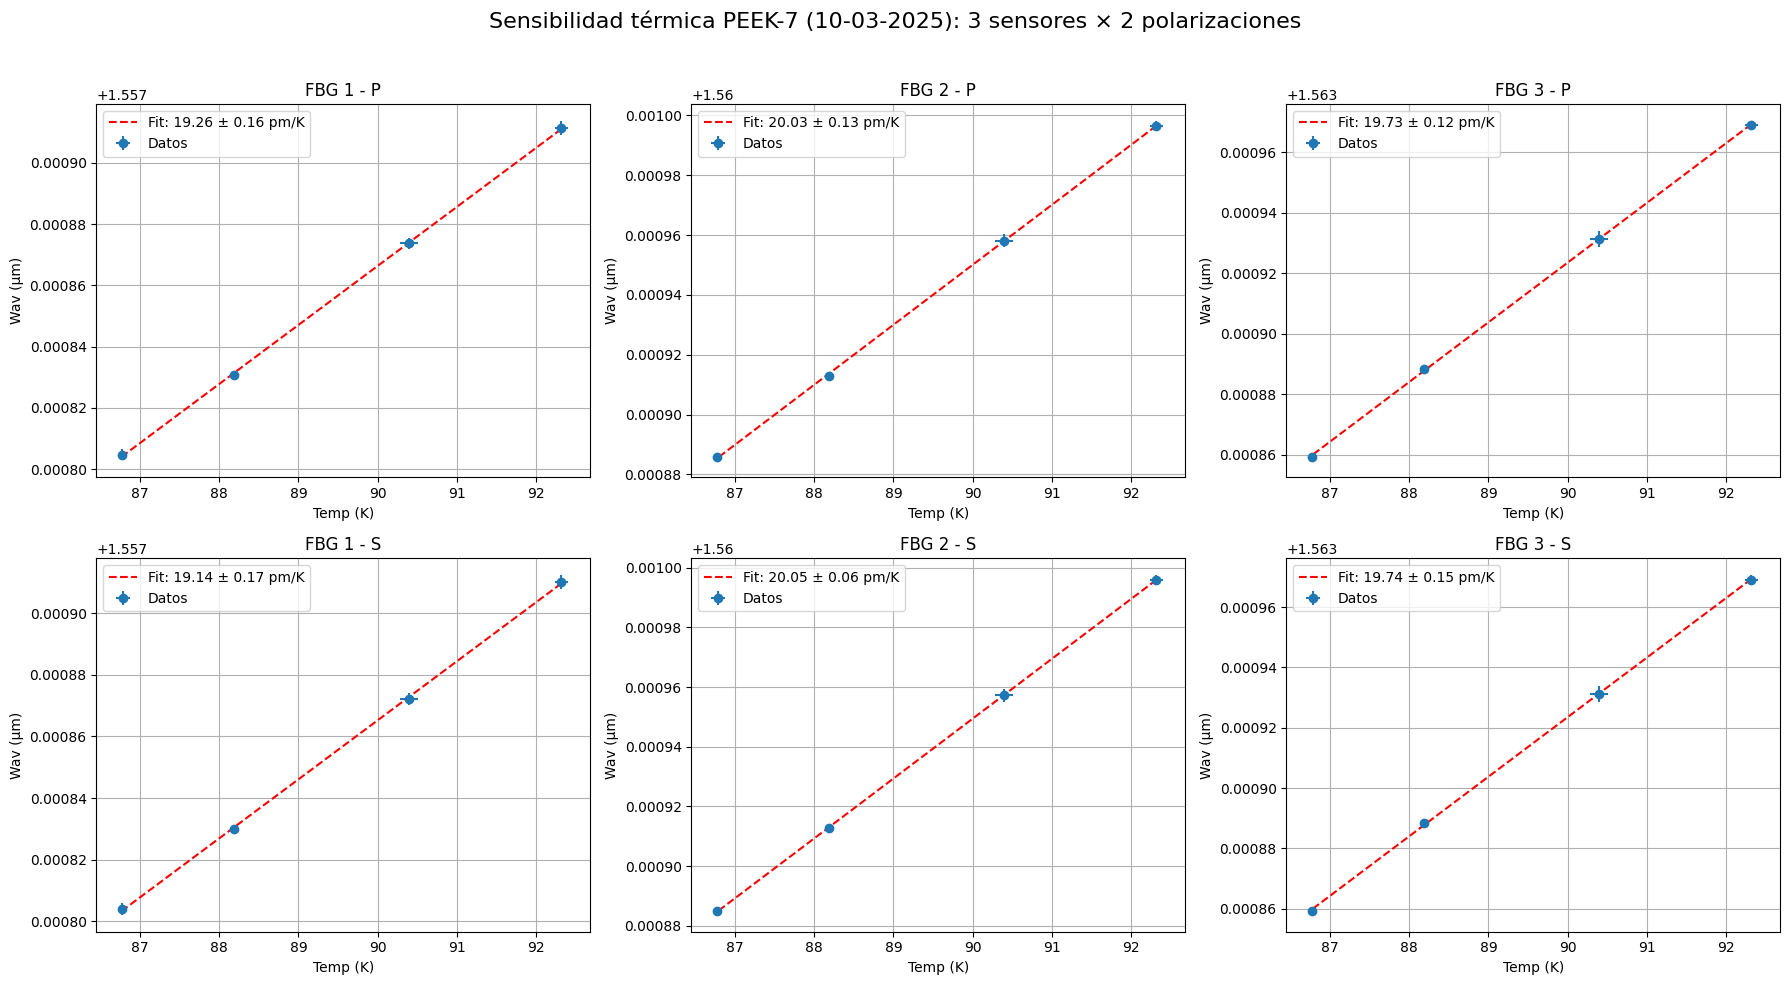

In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.stats import linregress

# --- Parámetros y plateaus específicos 10-03 ---
input_filename = '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/resampled20250310.root'

# Convertimos tu diccionario a la lista que espera el script
plateaus = [
    {"t0": "2025-03-10 14:39:31", "tfin": "2025-03-10 15:16:11"},
    {"t0": "2025-03-10 15:20:51", "tfin": "2025-03-10 15:42:21"},
    {"t0": "2025-03-10 16:00:51", "tfin": "2025-03-10 16:33:01"},
    {"t0": "2025-03-10 16:38:21", "tfin": "2025-03-10 17:01:31"},
]

# --- Cargar datos ---
with uproot.open(input_filename) as file:
    tree = file['resampled_data']
    data = tree.arrays(library='np')

times = data['t']
timestamps = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times])
temp = data['temp']
wav = data['wav']  # shape: (N, 2, 3) [pol, sensor]

# --- Función adaptada (formato de fecha sin milisegundos) ---
def get_plateau_stats(timestamps, values, plateaus, time_shift_hours=0):
    means, stds = [], []
    if time_shift_hours != 0:
        timestamps = np.array([t + datetime.timedelta(hours=time_shift_hours) for t in timestamps])
    for p in plateaus:
        # Ajustado a %Y-%m-%d %H:%M:%S porque los nuevos datos no tienen milisegundos
        t0 = datetime.datetime.strptime(p['t0'], '%Y-%m-%d %H:%M:%S')
        tfin = datetime.datetime.strptime(p['tfin'], '%Y-%m-%d %H:%M:%S')
        mask = (timestamps >= t0) & (timestamps <= tfin)
        vals = values[mask]
        means.append(np.mean(vals) if len(vals) > 0 else np.nan)
        stds.append(np.std(vals) if len(vals) > 0 else np.nan)
    return np.array(means), np.array(stds)

# --- Calcular medias y stds ---
results = {}
for pol in range(2):
    for sensor in range(3):
        wav_vals = wav[:, pol, sensor]
        # Umbrales (se mantienen los del sensor 0, 1, 2)
        if sensor == 0:
            umbral_min, umbral_max = 1.5570e-6, 1.5580e-6
        elif sensor == 1:
            umbral_min, umbral_max = 1.56e-6, 1.56148e-6
        else:
            umbral_min, umbral_max = 1.563e-6, 1.5642e-6
            
        mask = (wav_vals > umbral_min) & (wav_vals < umbral_max)
        wav_valid = wav_vals[mask]
        wav_times = timestamps[mask]
        
        # Aplicamos el shift de 1 hora pedido
        wav_means, wav_stds = get_plateau_stats(wav_times, wav_valid*1e6, plateaus, time_shift_hours=1)
        temp_means, temp_stds = get_plateau_stats(timestamps, temp[:,7], plateaus)
        
        results[(sensor, pol)] = {
            'wav_means': wav_means, 'wav_stds': wav_stds,
            'temp_means': temp_means, 'temp_stds': temp_stds
        }

# --- Graficar ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for idx, ((sensor, pol), res) in enumerate(results.items()):
    ax = axs[pol, sensor]
    mask = ~np.isnan(res['wav_means']) & ~np.isnan(res['temp_means'])
    if np.sum(mask) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(res['temp_means'][mask], res['wav_means'][mask])
        fit_line = slope * res['temp_means'][mask] + intercept
        ax.errorbar(res['temp_means'], res['wav_means'], xerr=res['temp_stds'], yerr=res['wav_stds'], fmt='o', label='Datos')
        ax.plot(res['temp_means'][mask], fit_line, 'r--', label=f'Fit: {slope*1e6:.2f} ± {std_err*1e6:.2f} pm/K')
        ax.set_title(f'FBG {sensor+1} - {"P" if pol==0 else "S"}')
        ax.set_xlabel('Temp (K)')
        ax.set_ylabel('Wav (μm)')
        ax.legend()
        ax.grid(True)

plt.suptitle('Sensibilidad térmica PEEK-7 (10-03-2025): 3 sensores × 2 polarizaciones', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [10]:
import pandas as pd

summary_data = []
fecha_experimento = "2025-03-10"

for (sensor_idx, pol_idx), res in results.items():
    mask = ~np.isnan(res["wav_means"]) & ~np.isnan(res["temp_means"])
    if np.sum(mask) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(
            res["temp_means"][mask], 
            res["wav_means"][mask]
        )
        # Convertimos a pm/K (slope ya está en um/K por el 1e6 de arriba)
        slope_pmk = slope * 1e6
        error_pmk = std_err * 1e6
        
        summary_data.append({
            "Date": fecha_experimento,
            "Sensor": f"FBG {sensor_idx + 1}",
            "Pol": "P" if pol_idx == 0 else "S",
            "Slope_pmK": round(slope_pmk, 3),
            "Error_pmK": round(error_pmk, 3),
            "R2": round(r_value**2, 5)
        })

df_results_10_03 = pd.DataFrame(summary_data)

print(f"Resumen de Sensibilidades - {fecha_experimento}")
print("-" * 60)
print(df_results_10_03.to_string(index=False))

Resumen de Sensibilidades - 2025-03-10
------------------------------------------------------------
      Date Sensor Pol  Slope_pmK  Error_pmK      R2
2025-03-10  FBG 1   P     19.258      0.164 0.99985
2025-03-10  FBG 2   P     20.034      0.133 0.99991
2025-03-10  FBG 3   P     19.733      0.124 0.99992
2025-03-10  FBG 1   S     19.138      0.171 0.99984
2025-03-10  FBG 2   S     20.046      0.056 0.99998
2025-03-10  FBG 3   S     19.739      0.147 0.99989


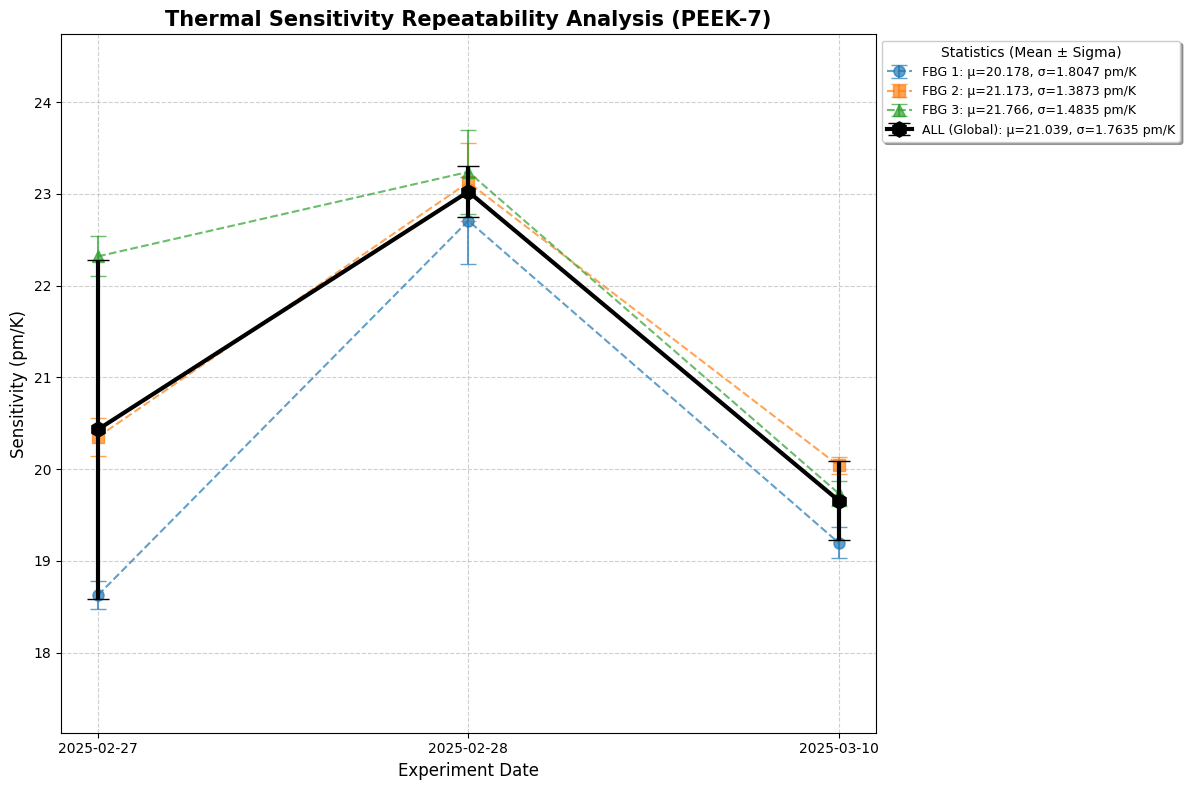


                             VERIFICATION TABLE: POLARIZATION MEAN                             
Date    2025-02-27  2025-02-28  2025-03-10  Mean (μ)  Sigma (σ)
Sensor                                                         
FBG 1      18.6265     22.7085      19.198   20.1777     2.2103
FBG 2      20.3530     23.1270      20.040   21.1733     1.6991
FBG 3      22.3200     23.2405      19.736   21.7655     1.8169
-----------------------------------------------------------------------------------------------
ALL (Network) Mean: 21.0388 pm/K | Sigma (Repeatability): 1.7635 pm/K


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Unificar los DataFrames de los 3 días
df_all_days = pd.concat([df_results_27_02, df_results_28_02, df_results_10_03])

# 2. Calcular la Media de Polarización (Media de P y S) por sensor y fecha
df_rep = df_all_days.groupby(['Date', 'Sensor']).agg({
    'Slope_pmK': 'mean',
    'Error_pmK': 'mean'  # Error promedio del fit
}).reset_index()

# 3. Calcular la serie "ALL" (Media de todos los sensores por día)
all_daily = df_rep.groupby('Date').agg({
    'Slope_pmK': ['mean', 'std']  # La media de la red y la dispersión entre sensores
}).reset_index()
all_daily.columns = ['Date', 'Mean_Slope', 'Std_Between_Sensors']

# Estadística global para la leyenda de "ALL"
mu_all = all_daily['Mean_Slope'].mean()
sigma_all = all_daily['Mean_Slope'].std()

# 4. Configuración del Plot
plt.figure(figsize=(12, 8))
dates = sorted(df_rep['Date'].unique())
sensors = sorted(df_rep['Sensor'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# Plot de sensores individuales
for i, sensor in enumerate(sensors):
    s_data = df_rep[df_rep['Sensor'] == sensor].sort_values('Date')
    vals = s_data['Slope_pmK'].values
    errs = s_data['Error_pmK'].values
    
    mu_s = np.mean(vals)
    sigma_s = np.std(vals)
    
    plt.errorbar(s_data['Date'], vals, yerr=errs, 
                 fmt=markers[i], color=colors[i], 
                 label=f'{sensor}: μ={mu_s:.3f}, σ={sigma_s:.4f} pm/K',
                 capsize=6, markersize=8, linestyle='--', linewidth=1.5, alpha=0.7)

# 5. Plot de la serie "ALL" (Black line) con sus barras de error
plt.errorbar(all_daily['Date'], all_daily['Mean_Slope'], 
             yerr=all_daily['Std_Between_Sensors'],
             fmt='h', color='black', label=f'ALL (Global): μ={mu_all:.3f}, σ={sigma_all:.4f} pm/K',
             capsize=8, markersize=11, linestyle='-', linewidth=3, zorder=10)

# 6. Estética y etiquetas
plt.title('Thermal Sensitivity Repeatability Analysis (PEEK-7)', fontsize=15, fontweight='bold')
plt.xlabel('Experiment Date', fontsize=12)
plt.ylabel('Sensitivity (pm/K)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Leyenda con cuadro informativo fuera del gráfico
plt.legend(title='Statistics (Mean ± Sigma)', fontsize=9, loc='upper left', 
           bbox_to_anchor=(1, 1), frameon=True, shadow=True)

# Ajuste de límites para que se vean bien las barras
plt.ylim(df_rep['Slope_pmK'].min() - 1.5, df_rep['Slope_pmK'].max() + 1.5)

plt.tight_layout()
plt.show()

# 7. Print de validación para comparar con tu tabla
print("\n" + "="*95)
print(f"{'VERIFICATION TABLE: POLARIZATION MEAN':^95}")
print("="*95)
check_table = df_rep.pivot(index='Sensor', columns='Date', values='Slope_pmK')
check_table['Mean (μ)'] = check_table.mean(axis=1)
check_table['Sigma (σ)'] = check_table.iloc[:, :3].std(axis=1)
print(check_table.round(4).to_string())
print("-" * 95)
print(f"ALL (Network) Mean: {mu_all:.4f} pm/K | Sigma (Repeatability): {sigma_all:.4f} pm/K")
print("="*95)

Nota sobre la selección de plateaus y el análisis por polarización
En las últimas celdas de este notebook, los plateaus temporales utilizados para el análisis de sensibilidad térmica se han definido de forma idéntica para las variables 'wav' y 'temp', y además se han aplicado los mismos intervalos a todas las polarizaciones y sensores.

¿Por qué puede esto inducir errores o sesgos?
Cada sensor y cada polarización pueden tener ligeros desfases temporales, respuestas distintas o incluso artefactos específicos en los datos.
Si se usan los mismos plateaus para todos, se ignoran posibles diferencias reales en el comportamiento de cada canal, lo que puede llevar a:
Subestimar o sobreestimar la sensibilidad real de algunos sensores/polarizaciones.
Introducir errores sistemáticos si, por ejemplo, un plateau incluye una transición o ruido en un canal pero no en otro.
En los análisis detallados de los notebooks individuales de cada día, se realizó una selección cuidadosa de plateaus para cada polarización y sensor, ajustando los intervalos para reflejar mejor la respuesta real de cada canal.
Diferencia con la tabla resumen
Los valores de la tabla resumen provienen de ese análisis detallado, donde se optimizó la selección de plateaus para cada caso.
Por eso, los resultados de la tabla resumen suelen ser más fiables y representativos de la sensibilidad real de cada sensor/polarización.
El análisis global y reproducible de las últimas celdas es útil para automatizar y comparar, pero puede perder precisión si no se ajustan los plateaus individualmente.
Recomendación:
Para obtener resultados más precisos y comparables, es preferible definir plateaus específicos para cada sensor y polarización, como se hizo en los análisis individuales, o al menos validar que los plateaus globales no introducen sesgos en ningún canal.

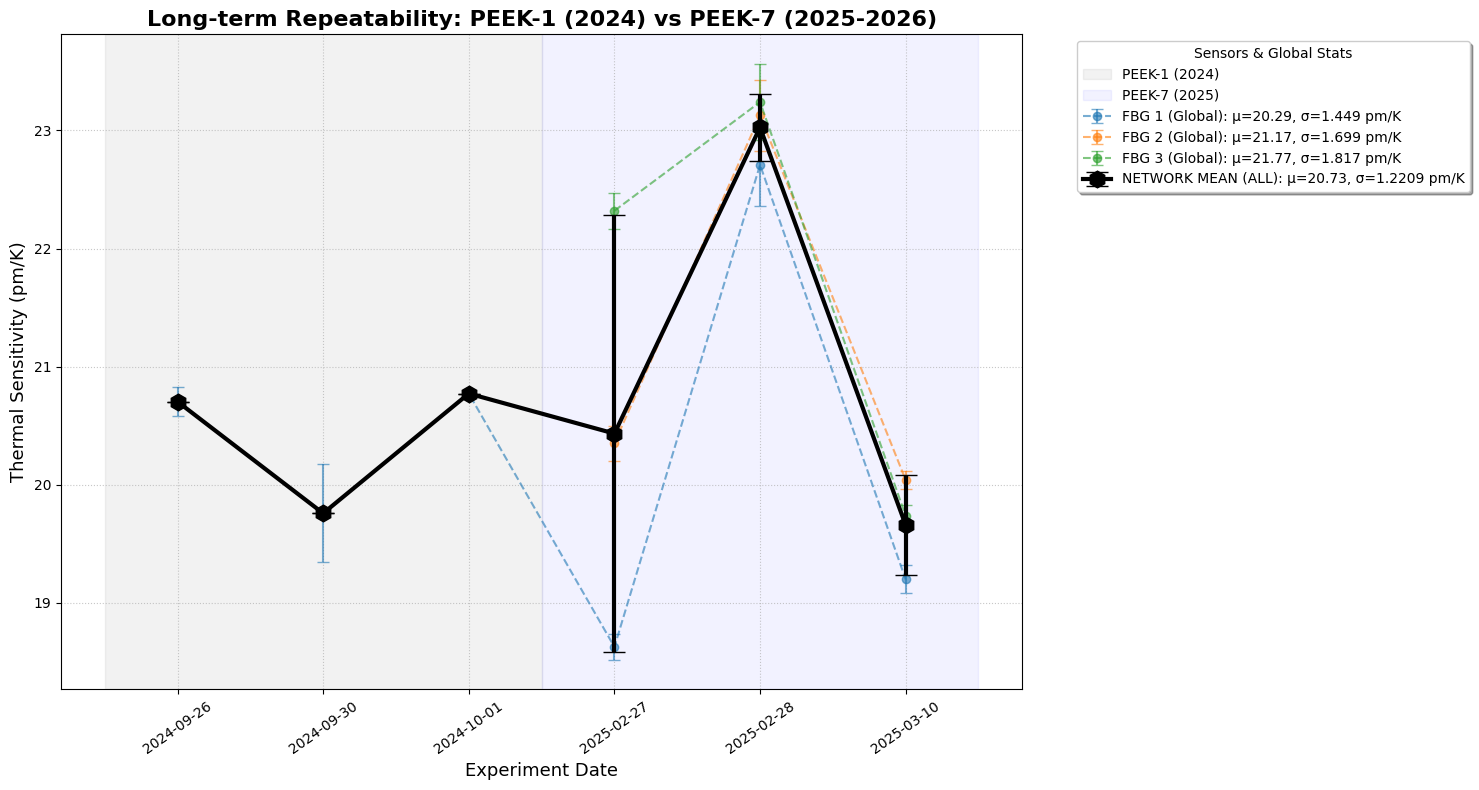


                                     HISTORICAL REPEATABILITY SUMMARY (PEEK-1 & PEEK-7)                                      
Date_str      2024-09-26 2024-09-30 2024-10-01 2025-02-27 2025-02-28 2025-03-10  Mean (μ)  Sigma (σ)
Fiber  Sensor                                                                                       
PEEK-1 FBG 1      20.704     19.758     20.772         -          -          -     20.411      0.463
PEEK-7 FBG 1          -          -          -      18.626     22.708     19.198    20.178      1.805
       FBG 2          -          -          -      20.353     23.127      20.04    21.173      1.387
       FBG 3          -          -          -       22.32      23.24     19.736    21.766      1.483
-----------------------------------------------------------------------------------------------------------------------------
OVERALL NETWORK STATISTICS: Mean = 20.725 pm/K | Sigma (Long-term Stability) = 1.2209 pm/K


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos 2024: Fibra PEEK-1 (Sept/Oct)
data_2024 = [
    {"Date": "2024-09-26", "Sensor": "FBG 1", "Pol": "P", "Slope_pmK": 20.785, "Error_pmK": 0.220, "Fiber": "PEEK-1"},
    {"Date": "2024-09-26", "Sensor": "FBG 1", "Pol": "S", "Slope_pmK": 20.622, "Error_pmK": 0.110, "Fiber": "PEEK-1"},
    {"Date": "2024-09-30", "Sensor": "FBG 1", "Pol": "P", "Slope_pmK": 19.323, "Error_pmK": 0.232, "Fiber": "PEEK-1"},
    {"Date": "2024-09-30", "Sensor": "FBG 1", "Pol": "S", "Slope_pmK": 20.193, "Error_pmK": 0.799, "Fiber": "PEEK-1"},
    {"Date": "2024-10-01", "Sensor": "FBG 1", "Pol": "P", "Slope_pmK": 20.669, "Error_pmK": 0.001, "Fiber": "PEEK-1"},
    {"Date": "2024-10-01", "Sensor": "FBG 1", "Pol": "S", "Slope_pmK": 20.875, "Error_pmK": 0.001, "Fiber": "PEEK-1"},
]
df_2024 = pd.DataFrame(data_2024)

# 2. Datos 2025-2026: Fibra PEEK-7 (Añadimos etiqueta de fibra a tus DFs existentes)
for df in [df_results_27_02, df_results_28_02, df_results_10_03]:
    df['Fiber'] = 'PEEK-7'

# 3. Consolidación Maestra
df_master = pd.concat([df_results_27_02, df_results_28_02, df_results_10_03, df_2024], ignore_index=True)

# Procesar Media de Polarización y agrupar por Fibra
df_rep = df_master.groupby(['Date', 'Sensor', 'Fiber']).agg({
    'Slope_pmK': 'mean',
    'Error_pmK': lambda x: np.sqrt(np.sum(np.square(x))) / len(x)
}).reset_index()

# Ordenar cronológicamente
df_rep['Date'] = pd.to_datetime(df_rep['Date'])
df_rep = df_rep.sort_values('Date')
df_rep['Date_str'] = df_rep['Date'].dt.strftime('%Y-%m-%d')

# 4. Estadística Global (ALL) - Unificando ambas fibras
all_daily = df_rep.groupby('Date_str').agg({'Slope_pmK': ['mean', 'std']}).reset_index()
all_daily.columns = ['Date_str', 'Mean_Slope', 'Std_Between_Sensors']
mu_all = all_daily['Mean_Slope'].mean()
sigma_all = all_daily['Mean_Slope'].std()

# 5. Plot de Repetibilidad Histórica
plt.figure(figsize=(15, 8))
sensors = sorted(df_rep['Sensor'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Colores consistentes para FBG 1, 2, 3

# Sombreado para diferenciar fibras
plt.axvspan(-0.5, 2.5, color='gray', alpha=0.1, label='PEEK-1 (2024)')
plt.axvspan(2.5, len(all_daily)-0.5, color='blue', alpha=0.05, label='PEEK-7 (2025)')

for i, sensor in enumerate(sensors):
    s_data = df_rep[df_rep['Sensor'] == sensor]
    # Estadística individual (histórica)
    mu_s = s_data['Slope_pmK'].mean()
    sigma_s = s_data['Slope_pmK'].std()
    
    plt.errorbar(s_data['Date_str'], s_data['Slope_pmK'], yerr=s_data['Error_pmK'],
                 label=f'{sensor} (Global): μ={mu_s:.2f}, σ={sigma_s:.3f} pm/K',
                 fmt='o--', color=colors[i], alpha=0.6, capsize=4)

# Serie ALL (Network Mean)
plt.errorbar(all_daily['Date_str'], all_daily['Mean_Slope'], yerr=all_daily['Std_Between_Sensors'].fillna(0),
             fmt='h-k', label=f'NETWORK MEAN (ALL): μ={mu_all:.2f}, σ={sigma_all:.4f} pm/K',
             capsize=8, markersize=12, linewidth=3, zorder=15)

# Estética y Etiquetas
plt.title('Long-term Repeatability: PEEK-1 (2024) vs PEEK-7 (2025-2026)', fontsize=16, fontweight='bold')
plt.ylabel('Thermal Sensitivity (pm/K)', fontsize=13)
plt.xlabel('Experiment Date', fontsize=13)
plt.xticks(rotation=35)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Sensors & Global Stats', bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True)

plt.tight_layout()
plt.show()

# 6. Tabla Resumen Histórica con Identificación de Fibra
print("\n" + "="*125)
print(f"{'HISTORICAL REPEATABILITY SUMMARY (PEEK-1 & PEEK-7)':^125}")
print("="*125)
pivot = df_rep.pivot_table(index=['Fiber', 'Sensor'], columns='Date_str', values='Slope_pmK')
pivot['Mean (μ)'] = pivot.mean(axis=1)
pivot['Sigma (σ)'] = pivot.std(axis=1)
print(pivot.round(3).fillna(" - ").to_string())
print("-" * 125)
print(f"OVERALL NETWORK STATISTICS: Mean = {mu_all:.3f} pm/K | Sigma (Long-term Stability) = {sigma_all:.4f} pm/K")
print("="*125)

en la celda siguiente junto las dos fibras de peek pero usando los resultados de los analisis de sensibilidad de los notebooks de peek7 individuales y no unos plateaus globales como en el plot de arriba.

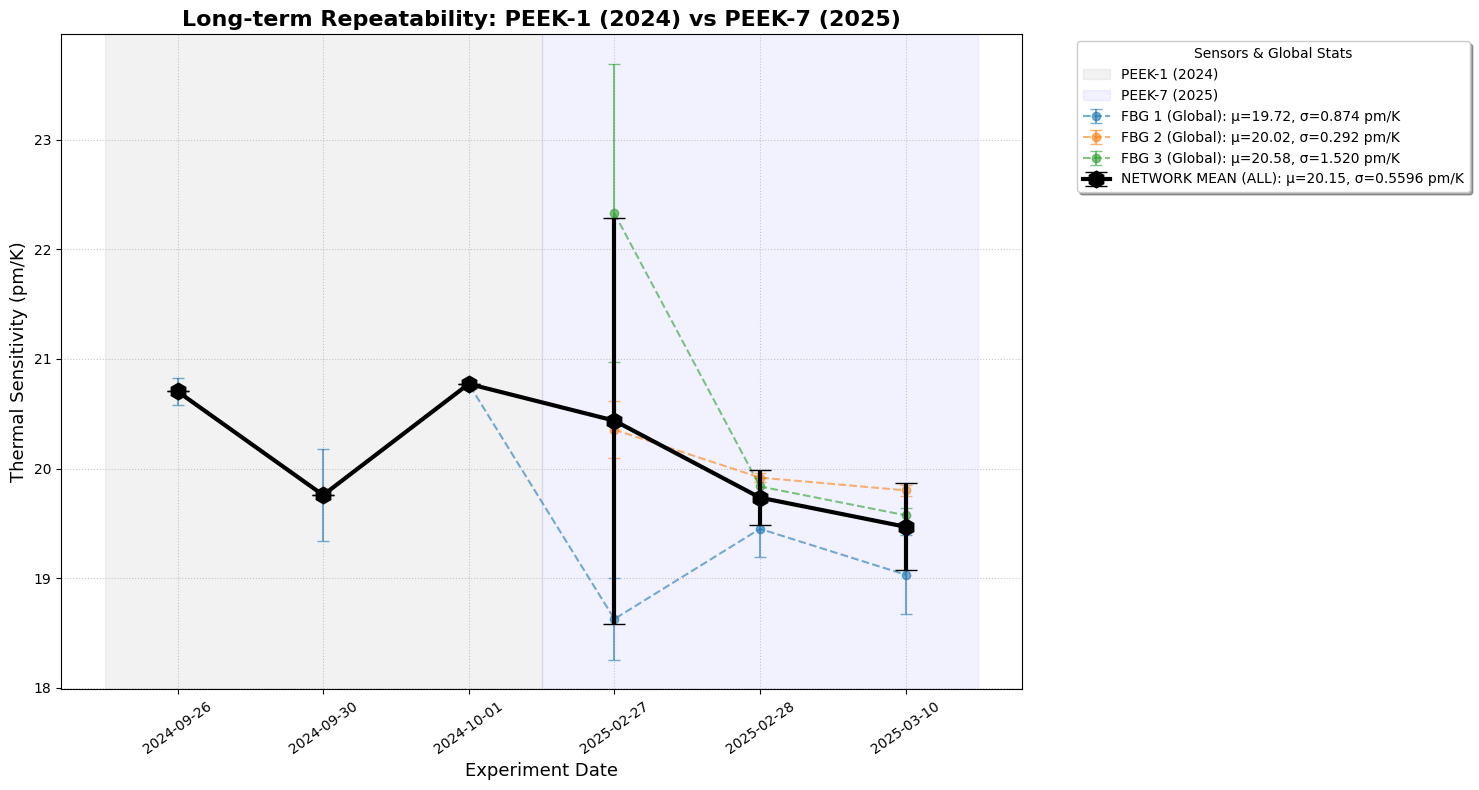


                                     HISTORICAL REPEATABILITY SUMMARY (PEEK-1 & PEEK-7)                                      
Date_str      2024-09-26 2024-09-30 2024-10-01 2025-02-27 2025-02-28 2025-03-10  Mean (μ)  Sigma (σ)
Fiber  Sensor                                                                                       
PEEK-1 FBG 1      20.704     19.758     20.772         -          -          -     20.411      0.463
PEEK-7 FBG 1          -          -          -      18.628      19.45     19.032    19.036      0.336
       FBG 2          -          -          -      20.354     19.918     19.801    20.024      0.238
       FBG 3          -          -          -      22.328     19.836     19.574    20.580      1.241
-----------------------------------------------------------------------------------------------------------------------------
OVERALL NETWORK STATISTICS: Mean = 20.146 pm/K | Sigma (Long-term Stability) = 0.5596 pm/K


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos 2024: Fibra PEEK-1 (Sept/Oct)
data_2024 = [
    {"Date": "2024-09-26", "Sensor": "FBG 1", "Slope_pmK": 20.785, "Error_pmK": 0.220, "Fiber": "PEEK-1"},
    {"Date": "2024-09-26", "Sensor": "FBG 1", "Slope_pmK": 20.622, "Error_pmK": 0.110, "Fiber": "PEEK-1"},
    {"Date": "2024-09-30", "Sensor": "FBG 1", "Slope_pmK": 19.323, "Error_pmK": 0.232, "Fiber": "PEEK-1"},
    {"Date": "2024-09-30", "Sensor": "FBG 1", "Slope_pmK": 20.193, "Error_pmK": 0.799, "Fiber": "PEEK-1"},
    {"Date": "2024-10-01", "Sensor": "FBG 1", "Slope_pmK": 20.669, "Error_pmK": 0.001, "Fiber": "PEEK-1"},
    {"Date": "2024-10-01", "Sensor": "FBG 1", "Slope_pmK": 20.875, "Error_pmK": 0.001, "Fiber": "PEEK-1"},
]
df_2024 = pd.DataFrame(data_2024)

# 2. Datos 2025: Fibra PEEK-7 (de tu primer plot, manual)
data_peek7 = [
    # Sensor 1
    {"Date": "2025-02-27", "Sensor": "FBG 1", "Slope_pmK": 18.6275, "Error_pmK": 0.37, "Fiber": "PEEK-7"},
    {"Date": "2025-02-28", "Sensor": "FBG 1", "Slope_pmK": 19.450, "Error_pmK": 0.26, "Fiber": "PEEK-7"},
    {"Date": "2025-03-10", "Sensor": "FBG 1", "Slope_pmK": 19.0315, "Error_pmK": 0.36, "Fiber": "PEEK-7"},
    # Sensor 2
    {"Date": "2025-02-27", "Sensor": "FBG 2", "Slope_pmK": 20.3545, "Error_pmK": 0.26, "Fiber": "PEEK-7"},
    {"Date": "2025-02-28", "Sensor": "FBG 2", "Slope_pmK": 19.9175, "Error_pmK": 0.04, "Fiber": "PEEK-7"},
    {"Date": "2025-03-10", "Sensor": "FBG 2", "Slope_pmK": 19.801, "Error_pmK": 0.05, "Fiber": "PEEK-7"},
    # Sensor 3
    {"Date": "2025-02-27", "Sensor": "FBG 3", "Slope_pmK": 22.3285, "Error_pmK": 1.36, "Fiber": "PEEK-7"},
    {"Date": "2025-02-28", "Sensor": "FBG 3", "Slope_pmK": 19.8365, "Error_pmK": 0.08, "Fiber": "PEEK-7"},
    {"Date": "2025-03-10", "Sensor": "FBG 3", "Slope_pmK": 19.574, "Error_pmK": 0.07, "Fiber": "PEEK-7"},
]
df_peek7 = pd.DataFrame(data_peek7)

# 3. Consolidación Maestra
df_master = pd.concat([df_2024, df_peek7], ignore_index=True)

# Procesar Media de Polarización y agrupar por Fibra y Sensor
df_rep = df_master.groupby(['Date', 'Sensor', 'Fiber']).agg({
    'Slope_pmK': 'mean',
    'Error_pmK': lambda x: np.sqrt(np.sum(np.square(x))) / len(x)
}).reset_index()

# Ordenar cronológicamente
df_rep['Date'] = pd.to_datetime(df_rep['Date'])
df_rep = df_rep.sort_values('Date')
df_rep['Date_str'] = df_rep['Date'].dt.strftime('%Y-%m-%d')

# 4. Estadística Global (ALL) - Unificando ambas fibras
all_daily = df_rep.groupby('Date_str').agg({'Slope_pmK': ['mean', 'std']}).reset_index()
all_daily.columns = ['Date_str', 'Mean_Slope', 'Std_Between_Sensors']
mu_all = all_daily['Mean_Slope'].mean()
sigma_all = all_daily['Mean_Slope'].std()

# 5. Plot de Repetibilidad Histórica
plt.figure(figsize=(15, 8))
sensors = sorted(df_rep['Sensor'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Colores consistentes para FBG 1, 2, 3

# Sombreado para diferenciar fibras
plt.axvspan(-0.5, 2.5, color='gray', alpha=0.1, label='PEEK-1 (2024)')
plt.axvspan(2.5, len(all_daily)-0.5, color='blue', alpha=0.05, label='PEEK-7 (2025)')

for i, sensor in enumerate(sensors):
    s_data = df_rep[df_rep['Sensor'] == sensor]
    mu_s = s_data['Slope_pmK'].mean()
    sigma_s = s_data['Slope_pmK'].std()
    plt.errorbar(s_data['Date_str'], s_data['Slope_pmK'], yerr=s_data['Error_pmK'],
                 label=f'{sensor} (Global): μ={mu_s:.2f}, σ={sigma_s:.3f} pm/K',
                 fmt='o--', color=colors[i], alpha=0.6, capsize=4)

# Serie ALL (Network Mean)
plt.errorbar(all_daily['Date_str'], all_daily['Mean_Slope'], yerr=all_daily['Std_Between_Sensors'].fillna(0),
             fmt='h-k', label=f'NETWORK MEAN (ALL): μ={mu_all:.2f}, σ={sigma_all:.4f} pm/K',
             capsize=8, markersize=12, linewidth=3, zorder=15)

plt.title('Long-term Repeatability: PEEK-1 (2024) vs PEEK-7 (2025)', fontsize=16, fontweight='bold')
plt.ylabel('Thermal Sensitivity (pm/K)', fontsize=13)
plt.xlabel('Experiment Date', fontsize=13)
plt.xticks(rotation=35)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title='Sensors & Global Stats', bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True)
plt.tight_layout()
plt.show()

# 6. Tabla Resumen Histórica con Identificación de Fibra
print("\n" + "="*125)
print(f"{'HISTORICAL REPEATABILITY SUMMARY (PEEK-1 & PEEK-7)':^125}")
print("="*125)
pivot = df_rep.pivot_table(index=['Fiber', 'Sensor'], columns='Date_str', values='Slope_pmK')
pivot['Mean (μ)'] = pivot.mean(axis=1)
pivot['Sigma (σ)'] = pivot.std(axis=1)
print(pivot.round(3).fillna(" - ").to_string())
print("-" * 125)
print(f"OVERALL NETWORK STATISTICS: Mean = {mu_all:.3f} pm/K | Sigma (Long-term Stability) = {sigma_all:.4f} pm/K")
print("="*125)